# 📦 Notebook 01 — Data Loading & Sampling
**Chicago Crime ML Pipeline**

This notebook is the **entry point** of the pipeline. It:
- Loads the raw `chicago.csv` in memory-efficient chunks
- Cleans and standardises columns
- Engineers base features shared across all tasks
- Exports **3 clean, ready-to-model datasets**:

| File | ML Task |
|---|---|
| `task1_arrest_prediction.csv` | Predict Arrest (Yes/No) |
| `task2_crime_type_prediction.csv` | Predict Crime Type |
| `task3_crime_count_per_area.csv` | Predict Crime Count per Area |

> **Next notebook:** `02_feature_engineering.ipynb`

---
## 1. Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Configuration ──────────────────────────────────────────────
RAW_FILE        = 'chicago.csv'
CHUNK_SIZE      = 1_000_000
SAMPLE_PER_CHUNK = 50_000   # ⚡ reduced for speed   # ↑ raise for more data, ↓ lower to save RAM
RANDOM_STATE    = 42
YEAR_RANGE      = (2002, 2025)
OUTPUT_DIR      = 'ml_data'   # all CSVs saved here

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output directory: {OUTPUT_DIR}/ ✅')

Output directory: ml_data/ ✅


---
## 2. Chunk-wise Loading & Basic Cleaning

In [2]:
def clean_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    """Apply row-level cleaning to a single chunk."""
    # ── Date parsing ──────────────────────────────────────────
    chunk['Date'] = pd.to_datetime(
        chunk['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce'
    )
    chunk = chunk.dropna(subset=['Date'])   # drop unparseable dates

    # ── Year filter ───────────────────────────────────────────
    chunk['Year'] = chunk['Date'].dt.year
    chunk = chunk[chunk['Year'].between(*YEAR_RANGE)]

    # ── Normalise boolean columns ─────────────────────────────
    for col in ['Arrest', 'Domestic']:
        chunk[col] = (
            chunk[col].astype(str).str.strip().str.upper()
            .map({'TRUE': True, 'FALSE': False})
        )

    # ── Strip & upper-case string columns ─────────────────────
    for col in ['Primary Type', 'Description', 'Location Description']:
        chunk[col] = chunk[col].astype(str).str.strip().str.upper()

    # ── Drop rows missing the target or key categorical cols ──
    chunk = chunk.dropna(subset=['Arrest', 'Primary Type'])

    return chunk


frames = []
total_raw = 0

for i, chunk in enumerate(pd.read_csv(RAW_FILE, chunksize=CHUNK_SIZE, low_memory=False)):
    total_raw += len(chunk)
    chunk = clean_chunk(chunk)

    # Stratified sample per chunk (balance arrest=True/False)
    chunk_arr   = chunk[chunk['Arrest'] == True].sample(
        min(SAMPLE_PER_CHUNK // 2, (chunk['Arrest'] == True).sum()),
        random_state=RANDOM_STATE
    )
    chunk_no_arr = chunk[chunk['Arrest'] == False].sample(
        min(SAMPLE_PER_CHUNK // 2, (chunk['Arrest'] == False).sum()),
        random_state=RANDOM_STATE
    )
    sampled = pd.concat([chunk_arr, chunk_no_arr], ignore_index=True)
    frames.append(sampled)

    print(f'Chunk {i:02d} | raw: {len(chunk):>8,} | sampled: {len(sampled):>7,} '
          f'| arrests: {len(chunk_arr):,} | non-arrests: {len(chunk_no_arr):,}')

df = pd.concat(frames, ignore_index=True)
print(f'\n✅ Total raw rows read  : {total_raw:,}')
print(f'✅ Working dataset size : {len(df):,} rows × {df.shape[1]} cols')

Chunk 00 | raw:  532,093 | sampled:  50,000 | arrests: 25,000 | non-arrests: 25,000
Chunk 01 | raw:  999,233 | sampled:  50,000 | arrests: 25,000 | non-arrests: 25,000
Chunk 02 | raw:  994,913 | sampled:  50,000 | arrests: 25,000 | non-arrests: 25,000
Chunk 03 | raw:  988,293 | sampled:  50,000 | arrests: 25,000 | non-arrests: 25,000
Chunk 04 | raw:   75,553 | sampled:  47,054 | arrests: 22,054 | non-arrests: 25,000

✅ Total raw rows read  : 4,075,568
✅ Working dataset size : 247,054 rows × 22 cols


---
## 3. Dataset Overview

In [3]:
print('── Shape ──────────────────────────────────')
print(f'Rows: {df.shape[0]:,}   Cols: {df.shape[1]}')

print('\n── Column Info ────────────────────────────')
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non_null': df.notna().sum(),
    'null_%'  : (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique()
})
print(info.to_string())

print('\n── Sample Rows ────────────────────────────')
df.head(3)

── Shape ──────────────────────────────────
Rows: 247,054   Cols: 22

── Column Info ────────────────────────────
                               dtype  non_null  null_%  n_unique
ID                            object    247054    0.00    247054
Case Number                   object    247054    0.00    247040
Date                  datetime64[ns]    247054    0.00    204945
Block                         object    247054    0.00     32591
IUCR                          object    247054    0.00       352
Primary Type                  object    247054    0.00        32
Description                   object    247054    0.00       419
Location Description          object    247054    0.00       172
Arrest                          bool    247054    0.00         2
Domestic                        bool    247054    0.00         2
Beat                         float64    247054    0.00       303
District                     float64    247050    0.00        23
Ward                         float64    2

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,2145677,HH380987,2002-05-18 19:24:39,103XX S MICHIGAN AVE,0820,THEFT,$500 AND UNDER,DRUG STORE,True,False,...,9.0,49.0,06,1178964.0,1836624.0,2002,02/28/2018 03:56:25 PM,41.706987,-87.6202,"(41.706987456, -87.620244029)"
1,2491088,HH813872,2002-12-02 15:05:00,015XX N HALSTED ST,2027,NARCOTICS,POSS: CRACK,ALLEY,True,False,...,27.0,8.0,18,1170733.0,1910288.0,2002,02/10/2018 03:50:01 PM,41.909312,-87.6482,"(41.909312244, -87.648235435)"
2,27856,JG500277,2023-11-11 15:20:00,130XX S DREXEL AVE,0110,HOMICIDE,FIRST DEGREE MURDER,CHA APARTMENT,True,False,...,10.0,54.0,01A,1184678.0,1818786.0,2023,02/22/2024 03:40:45 PM,41.657906,-87.5999,"(41.657905826, -87.599875727)"


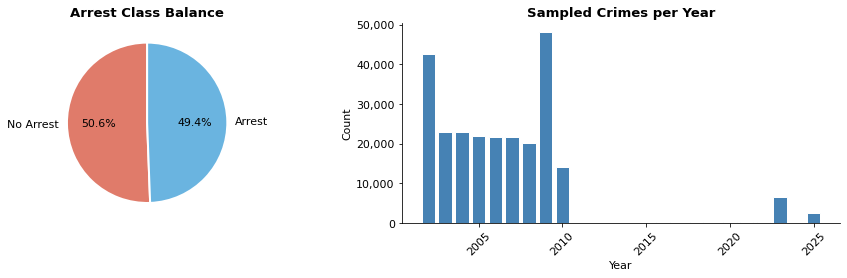

In [4]:
# ── Arrest class balance ──────────────────────────────────────
vc = df['Arrest'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie
axes[0].pie(vc, labels=['No Arrest', 'Arrest'], autopct='%1.1f%%',
            colors=['#e07b6a', '#6ab4e0'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Arrest Class Balance', fontweight='bold')

# Crimes by year
yr_counts = df.groupby('Year').size().reset_index(name='Count')
axes[1].bar(yr_counts['Year'], yr_counts['Count'], color='steelblue', edgecolor='white')
axes[1].set_title('Sampled Crimes per Year', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

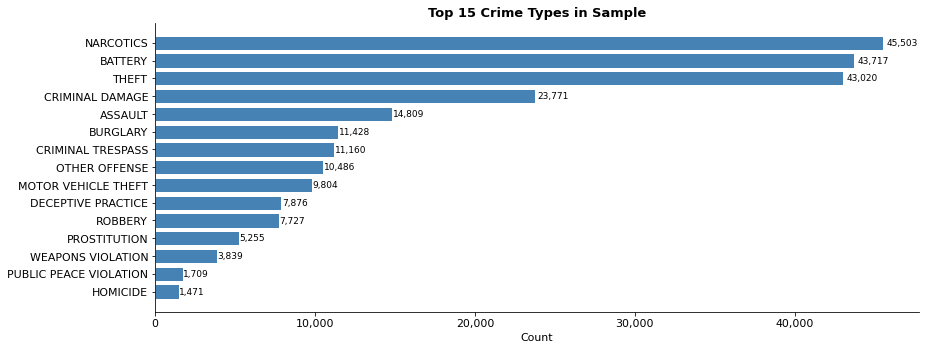

In [5]:
# ── Top 15 crime types ────────────────────────────────────────
top15 = df['Primary Type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color='steelblue', edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Top 15 Crime Types in Sample', fontweight='bold', fontsize=13)
ax.set_xlabel('Count')
for bar in bars:
    w = bar.get_width()
    ax.text(w + w * 0.005, bar.get_y() + bar.get_height() / 2,
            f'{int(w):,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_top_crime_types.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Shared Feature Engineering
These features are computed once and shared across all 3 tasks.

In [6]:
def add_datetime_features(df):
    df['Hour']        = df['Date'].dt.hour
    df['DayOfWeek']   = df['Date'].dt.dayofweek          # 0=Mon … 6=Sun
    df['Month']       = df['Date'].dt.month
    df['Quarter']     = df['Date'].dt.quarter
    df['Year']        = df['Date'].dt.year
    df['IsWeekend']   = df['DayOfWeek'].isin([5, 6]).astype(int)
    df['IsNight']     = df['Hour'].between(22, 23) | df['Hour'].between(0, 5)
    df['IsNight']     = df['IsNight'].astype(int)
    df['Season']      = df['Month'].map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring',  4: 'Spring', 5: 'Spring',
        6: 'Summer',  7: 'Summer', 8: 'Summer',
        9: 'Fall',   10: 'Fall', 11: 'Fall'
    })
    return df

df = add_datetime_features(df)

# Domestic flag as int
df['Domestic'] = df['Domestic'].astype(int)

# Arrest as int
df['ArrestInt'] = df['Arrest'].astype(int)

print('DateTime features added ✅')
print(df[['Hour','DayOfWeek','Month','Quarter','IsWeekend','IsNight','Season']].head(3))

DateTime features added ✅
   Hour  DayOfWeek  Month  Quarter  IsWeekend  IsNight  Season
0    19          5      5        2          1        0  Spring
1    15          0     12        4          0        0  Winter
2    15          5     11        4          1        0    Fall


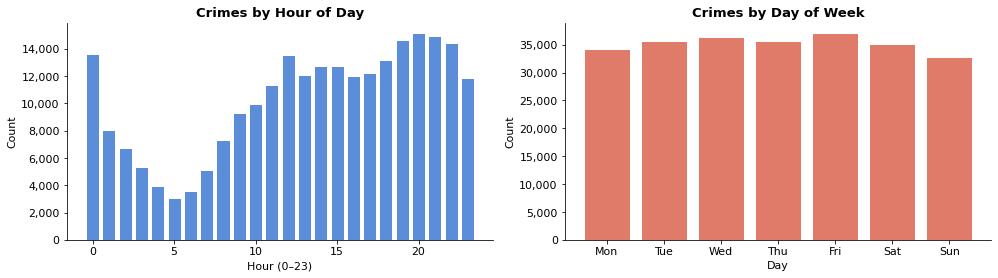

In [7]:
# ── Hourly crime distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hour_counts = df.groupby('Hour').size()
axes[0].bar(hour_counts.index, hour_counts.values, color='#5b8dd9', edgecolor='white')
axes[0].set_title('Crimes by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (0–23)'); axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Day of week
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_counts = df.groupby('DayOfWeek').size()
axes[1].bar(day_labels, dow_counts.values, color='#e07b6a', edgecolor='white')
axes[1].set_title('Crimes by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_time_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Export Dataset 1 — Arrest Prediction
**Target:** `Arrest` (binary: 0 = No, 1 = Yes)  
**Features:** time features + crime type + location description + domestic flag

In [8]:
TASK1_FEATURES = [
    'Primary Type', 'Description', 'Location Description',
    'Domestic', 'Hour', 'DayOfWeek', 'Month', 'Quarter',
    'Year', 'IsWeekend', 'IsNight', 'Season'
]
TASK1_TARGET = 'ArrestInt'

task1 = df[TASK1_FEATURES + [TASK1_TARGET]].copy()
task1 = task1.dropna()

path1 = f'{OUTPUT_DIR}/task1_arrest_prediction.csv'
task1.to_csv(path1, index=False)

print(f'✅ Task 1 saved → {path1}')
print(f'   Shape  : {task1.shape}')
print(f'   Target : ArrestInt  |  0={( task1[TASK1_TARGET]==0).sum():,}  |  1={(task1[TASK1_TARGET]==1).sum():,}')
task1.head(3)

✅ Task 1 saved → ml_data/task1_arrest_prediction.csv
   Shape  : (247054, 13)
   Target : ArrestInt  |  0=125,000  |  1=122,054


,Primary Type,Description,Location Description,Domestic,Hour,DayOfWeek,Month,Quarter,Year,IsWeekend,IsNight,Season,ArrestInt
0,THEFT,$500 AND UNDER,DRUG STORE,0,19,5,5,2,2002,1,0,Spring,1
1,NARCOTICS,POSS: CRACK,ALLEY,0,15,0,12,4,2002,0,0,Winter,1
2,HOMICIDE,FIRST DEGREE MURDER,CHA APARTMENT,0,15,5,11,4,2023,1,0,Fall,1


---
## 6. Export Dataset 2 — Crime Type Prediction
**Target:** `Primary Type` (multi-class)  
**Features:** time features + location description + domestic flag + arrest flag  
We keep only the **top 10 crime types** to keep the classification tractable.

In [9]:
TOP_N_TYPES = 10
top_types = df['Primary Type'].value_counts().head(TOP_N_TYPES).index.tolist()

task2_df = df[df['Primary Type'].isin(top_types)].copy()

TASK2_FEATURES = [
    'Location Description', 'Domestic', 'ArrestInt',
    'Hour', 'DayOfWeek', 'Month', 'Quarter',
    'Year', 'IsWeekend', 'IsNight', 'Season'
]
TASK2_TARGET = 'Primary Type'

task2 = task2_df[TASK2_FEATURES + [TASK2_TARGET]].copy()
task2 = task2.dropna()

path2 = f'{OUTPUT_DIR}/task2_crime_type_prediction.csv'
task2.to_csv(path2, index=False)

print(f'✅ Task 2 saved → {path2}')
print(f'   Shape   : {task2.shape}')
print(f'   Classes : {task2[TASK2_TARGET].nunique()}')
print(task2[TASK2_TARGET].value_counts().to_string())

✅ Task 2 saved → ml_data/task2_crime_type_prediction.csv
   Shape   : (221574, 12)
   Classes : 10
NARCOTICS              45503
BATTERY                43717
THEFT                  43020
CRIMINAL DAMAGE        23771
ASSAULT                14809
BURGLARY               11428
CRIMINAL TRESPASS      11160
OTHER OFFENSE          10486
MOTOR VEHICLE THEFT     9804
DECEPTIVE PRACTICE      7876


---
## 7. Export Dataset 3 — Crime Count per Area
**Target:** `CrimeCount` (regression — daily crimes per community area)  
**Features:** area ID + time features

In [10]:
# Aggregate to daily counts per community area
df['Date_Day'] = df['Date'].dt.normalize()   # floor to midnight

task3 = (
    df.dropna(subset=['Community Area'])
    .groupby(['Community Area', 'Date_Day', 'Year', 'Month', 'Quarter', 'DayOfWeek', 'IsWeekend', 'Season'])
    .size()
    .reset_index(name='CrimeCount')
)

# Add lag features: rolling mean of past 7 days per area
task3 = task3.sort_values(['Community Area', 'Date_Day'])
task3['Rolling7d'] = (
    task3.groupby('Community Area')['CrimeCount']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

path3 = f'{OUTPUT_DIR}/task3_crime_count_per_area.csv'
task3.to_csv(path3, index=False)

print(f'✅ Task 3 saved → {path3}')
print(f'   Shape  : {task3.shape}')
print(f'   Target : CrimeCount  |  mean={task3["CrimeCount"].mean():.2f}  |  max={task3["CrimeCount"].max()}')
task3.head(3)

✅ Task 3 saved → ml_data/task3_crime_count_per_area.csv
   Shape  : (119374, 10)
   Target : CrimeCount  |  mean=1.96  |  max=39


,Community Area,Date_Day,Year,Month,Quarter,DayOfWeek,IsWeekend,Season,CrimeCount,Rolling7d
0,0.0,2002-07-09,2002,7,3,1,0,Summer,1,NaN
1,0.0,2003-12-16,2003,12,4,1,0,Winter,1,1.0
2,0.0,2008-07-26,2008,7,3,5,1,Summer,1,1.0


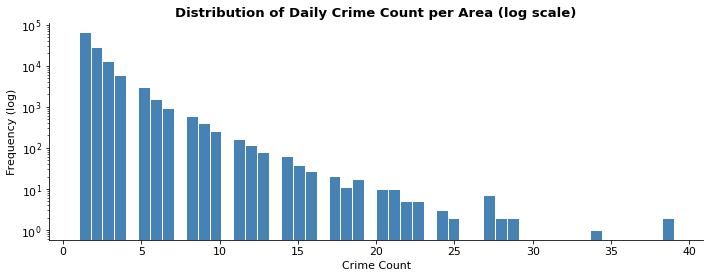

In [11]:
# Crime count distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(task3['CrimeCount'], bins=50, color='steelblue', edgecolor='white', log=True)
ax.set_title('Distribution of Daily Crime Count per Area (log scale)', fontweight='bold')
ax.set_xlabel('Crime Count'); ax.set_ylabel('Frequency (log)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_crime_count_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Summary

In [12]:
print('=' * 62)
print('       NOTEBOOK 01 — DATA LOADING & SAMPLING COMPLETE')
print('=' * 62)
print(f'  Raw rows read              : {total_raw:>12,}')
print(f'  Working sample size        : {len(df):>12,}')
print(f'  Years covered              : {int(df["Year"].min())} – {int(df["Year"].max())}')
print(f'  Arrest rate in sample      : {df["ArrestInt"].mean()*100:.1f}%')
print()
print(f'  📁 Task 1 — Arrest Pred.  : task1_arrest_prediction.csv      ({len(task1):,} rows)')
print(f'  📁 Task 2 — Crime Type    : task2_crime_type_prediction.csv   ({len(task2):,} rows)')
print(f'  📁 Task 3 — Crime Count   : task3_crime_count_per_area.csv    ({len(task3):,} rows)')
print()
print('  ➡️  Next: 02_feature_engineering.ipynb')
print('=' * 62)

       NOTEBOOK 01 — DATA LOADING & SAMPLING COMPLETE
  Raw rows read              :    4,075,568
  Working sample size        :      247,054
  Years covered              : 2002 – 2025
  Arrest rate in sample      : 49.4%

  📁 Task 1 — Arrest Pred.  : task1_arrest_prediction.csv      (247,054 rows)
  📁 Task 2 — Crime Type    : task2_crime_type_prediction.csv   (221,574 rows)
  📁 Task 3 — Crime Count   : task3_crime_count_per_area.csv    (119,374 rows)

  ➡️  Next: 02_feature_engineering.ipynb
